# Asset Health Monitoring
## Notebook 02 - Preprocessing & Feature Engineering

**Input:** 5 file CSV raw dari Kaggle  
**Output:** `data/processed/features.parquet` — master feature table siap untuk modeling  

### Yang dilakukan di notebook ini
1. Merge 5 tabel menjadi satu master dataset
2. Handle missing values
3. Rolling statistics (3h, 24h) untuk setiap sensor
4. Lag features (t-1, t-3, t-6)
5. Error count aggregation per window waktu
6. Days since last maintenance
7. Label engineering: hours-to-failure
8. Normalisasi dengan StandardScaler
9. Simpan ke parquet + scaler pickle


In [1]:
import os
# Auto-detect root: works both in Jupyter and nbconvert
try:
    ROOT = os.path.abspath(os.path.join(os.path.dirname(__file__), '..'))
except NameError:
    # Jupyter kernel: __file__ tidak ada, pakai getcwd()
    ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

DATA_DIR    = os.path.join(ROOT, 'data', 'raw')
PROC_DIR    = os.path.join(ROOT, 'data', 'processed')
MODELS_DIR  = os.path.join(ROOT, 'models')
FIGURES_DIR = os.path.join(ROOT, 'reports', 'figures')

for d in [PROC_DIR, MODELS_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

print(f'ROOT       : {ROOT}')
print(f'DATA_DIR   : {DATA_DIR}')
print(f'FIGURES_DIR: {FIGURES_DIR}')


ROOT       : /Users/aryautomo/Documents/6th Term/EDM/Project/asset-health-monitoring
DATA_DIR   : /Users/aryautomo/Documents/6th Term/EDM/Project/asset-health-monitoring/data/raw
FIGURES_DIR: /Users/aryautomo/Documents/6th Term/EDM/Project/asset-health-monitoring/reports/figures


## 0. Setup

In [2]:
import os, warnings, joblib
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({
    "figure.facecolor":"white","axes.facecolor":"white",
    "axes.grid":True,"grid.alpha":0.3,"grid.linestyle":"--",
    "font.size":11,"axes.titlesize":13,"axes.titleweight":"bold","figure.dpi":120
})

DATA_DIR    = os.path.join(os.path.abspath(os.path.join(os.getcwd(), '..')), 'data', 'raw')
PROC_DIR    = os.path.join(ROOT, 'data', 'processed')
MODELS_DIR  = os.path.join(ROOT, 'models')
FIGURES_DIR = os.path.join(ROOT, 'reports', 'figures')
for d in [PROC_DIR, MODELS_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

SENSOR_COLS = ['volt','rotate','pressure','vibration']
WINDOWS     = [3, 24]   # jam
LAG_HOURS   = [1, 3, 6]

print('Setup complete')


Setup complete


## 1. Load Raw Data

In [3]:
telemetry   = pd.read_csv(f'{DATA_DIR}/PdM_telemetry.csv',  parse_dates=['datetime'])
errors      = pd.read_csv(f'{DATA_DIR}/PdM_errors.csv',     parse_dates=['datetime'])
failures    = pd.read_csv(f'{DATA_DIR}/PdM_failures.csv',   parse_dates=['datetime'])
maintenance = pd.read_csv(f'{DATA_DIR}/PdM_maint.csv',      parse_dates=['datetime'])
machines    = pd.read_csv(f'{DATA_DIR}/PdM_machines.csv')

# Standardise column names (Kaggle file sometimes uses 'comp' or 'failure')
if 'comp' in maintenance.columns:
    maintenance = maintenance.rename(columns={'comp':'component'})

print(f'Telemetry : {len(telemetry):,} rows')
print(f'Errors    : {len(errors):,} rows')
print(f'Failures  : {len(failures):,} rows')
print(f'Maint     : {len(maintenance):,} rows')
print(f'Machines  : {len(machines):,} rows')


Telemetry : 876,100 rows
Errors    : 3,919 rows
Failures  : 761 rows
Maint     : 3,286 rows
Machines  : 100 rows


## 2. Sort & Merge with Machine Metadata

In [4]:
# Sort by machine + time — critical for rolling calculations
df = telemetry.sort_values(['machineID','datetime']).reset_index(drop=True)

# Attach machine metadata (model, age)
df = df.merge(machines, on='machineID', how='left')

# Encode model as integer for model features
df['model_code'] = df['model'].astype('category').cat.codes

print(f'Master shape after base merge: {df.shape}')
print(f'Machines covered: {df["machineID"].nunique()}')
print(f'Date range: {df["datetime"].min()} -> {df["datetime"].max()}')
display(df.head(3))


Master shape after base merge: (876100, 9)
Machines covered: 100
Date range: 2015-01-01 06:00:00 -> 2016-01-01 06:00:00


,datetime,machineID,volt,rotate,pressure,vibration,model,age,model_code
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686,model3,18,2
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973,model3,18,2
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847,model3,18,2


## 3. Rolling Window Features

Untuk setiap sensor, hitung **mean** dan **std** dalam window 3 jam dan 24 jam.
Ini menangkap tren jangka pendek dan jangka menengah.

Penting: rolling dilakukan **per mesin** (`groupby machineID`) agar tidak bocor antar mesin.


In [5]:
print('Computing rolling features...')

for sensor in SENSOR_COLS:
    grp = df.groupby('machineID')[sensor]
    for w in WINDOWS:
        df[f'{sensor}_mean{w}h'] = grp.transform(
            lambda x: x.rolling(w, min_periods=1).mean()
        )
        df[f'{sensor}_std{w}h'] = grp.transform(
            lambda x: x.rolling(w, min_periods=1).std().fillna(0)
        )
    # Rate of change (delta antara reading sekarang dan 1 jam lalu)
    df[f'{sensor}_roc'] = grp.transform(lambda x: x.diff().fillna(0))

rolling_cols = [c for c in df.columns if any(
    c.endswith(s) for s in ['mean3h','mean24h','std3h','std24h','roc']
)]
print(f'Rolling features added: {len(rolling_cols)} columns')
print(rolling_cols)


Computing rolling features...


Rolling features added: 20 columns
['volt_mean3h', 'volt_std3h', 'volt_mean24h', 'volt_std24h', 'volt_roc', 'rotate_mean3h', 'rotate_std3h', 'rotate_mean24h', 'rotate_std24h', 'rotate_roc', 'pressure_mean3h', 'pressure_std3h', 'pressure_mean24h', 'pressure_std24h', 'pressure_roc', 'vibration_mean3h', 'vibration_std3h', 'vibration_mean24h', 'vibration_std24h', 'vibration_roc']


## 4. Lag Features

In [6]:
print('Computing lag features...')

for sensor in SENSOR_COLS:
    for lag in LAG_HOURS:
        df[f'{sensor}_lag{lag}h'] = (
            df.groupby('machineID')[sensor]
              .shift(lag)
        )

lag_cols = [c for c in df.columns if '_lag' in c]
print(f'Lag features added: {len(lag_cols)} columns')

# Drop rows with NaN from lag (first few rows per machine)
# We fill with forward fill then backfill to keep all rows
df[lag_cols] = df[lag_cols].fillna(method='ffill').fillna(method='bfill')
print(f'NaN after fill: {df[lag_cols].isnull().sum().sum()}')


Computing lag features...
Lag features added: 12 columns
NaN after fill: 0


## 5. Error Count Features

Hitung berapa kali setiap error type muncul dalam 24 jam terakhir per mesin.
Error yang sering muncul sebelum failure adalah sinyal kuat untuk model.


In [7]:
print('Computing error count features...')

# Round errors to nearest hour (sudah rounded di dataset, tapi pastikan)
errors['datetime'] = errors['datetime'].dt.floor('h')

error_types = sorted(errors['errorID'].unique())
print(f'Error types: {error_types}')

# For each row in df, count errors per type in last 24h per machine
# Efficient approach: pivot errors then rolling sum
err_pivot = (
    errors
    .assign(count=1)
    .pivot_table(index=['machineID','datetime'], columns='errorID',
                 values='count', aggfunc='sum', fill_value=0)
    .reset_index()
)
err_pivot.columns.name = None
err_cols = [c for c in err_pivot.columns if c.startswith('error')]

# Merge with main df on machineID + datetime
df = df.merge(err_pivot, on=['machineID','datetime'], how='left')
df[err_cols] = df[err_cols].fillna(0)

# Rolling 24h sum per machine per error type
for ec in err_cols:
    df[f'{ec}_count24h'] = (
        df.groupby('machineID')[ec]
          .transform(lambda x: x.rolling(24, min_periods=1).sum())
    )

# Total error count across all types
df['total_error_count24h'] = df[[f'{ec}_count24h' for ec in err_cols]].sum(axis=1)

err_feat_cols = [c for c in df.columns if 'count24h' in c]
print(f'Error features added: {len(err_feat_cols)} columns')
print(f'Max total errors in 24h: {df["total_error_count24h"].max()}')


Computing error count features...
Error types: ['error1', 'error2', 'error3', 'error4', 'error5']


Error features added: 6 columns
Max total errors in 24h: 4.0


## 6. Days Since Last Maintenance

In [8]:
print('Computing days since last maintenance...')

# For each machine, for each timestamp, find the most recent maintenance before it
maintenance_sorted = maintenance.sort_values(['machineID','datetime'])

def days_since_maint(machine_df, maint_df):
    mid = machine_df['machineID'].iloc[0]
    m_times = maint_df[maint_df['machineID']==mid]['datetime'].values
    if len(m_times) == 0:
        return pd.Series(999.0, index=machine_df.index)
    result = []
    for dt in machine_df['datetime']:
        past = m_times[m_times <= np.datetime64(dt)]
        if len(past) == 0:
            result.append(999.0)  # tidak ada maintenance sebelumnya
        else:
            delta = (dt - pd.Timestamp(past[-1])).total_seconds() / 86400
            result.append(delta)
    return pd.Series(result, index=machine_df.index)

# Apply per machine (bisa memakan waktu 1-2 menit)
print('Processing... (estimasi 1-2 menit)')
dsm = df.groupby('machineID', group_keys=False).apply(
    lambda g: days_since_maint(g, maintenance_sorted)
)
df['days_since_maint'] = dsm.values
df['days_since_maint'] = df['days_since_maint'].clip(0, 365)

print(f'days_since_maint stats:')
print(df['days_since_maint'].describe().round(2))


Computing days since last maintenance...
Processing... (estimasi 1-2 menit)


days_since_maint stats:
count    876100.00
mean         10.98
std          13.42
min           0.00
25%           4.25
50%           8.54
75%          12.88
max         169.96
Name: days_since_maint, dtype: float64


## 7. Label Engineering: Hours to Next Failure

Untuk evaluasi model nanti, kita buat kolom `hours_to_failure` dan `will_fail_24h`.
**Catatan:** kolom ini TIDAK digunakan sebagai feature training Isolation Forest
(model unsupervised), tapi dipakai sebagai ground truth untuk evaluasi.


In [9]:
print('Engineering failure labels...')

df['hours_to_failure'] = np.inf
df['failure_type']     = None

for mid in df['machineID'].unique():
    mfail = failures[failures['machineID']==mid].sort_values('datetime')
    if len(mfail) == 0:
        continue
    mask = df['machineID'] == mid
    for _, frow in mfail.iterrows():
        ft = frow['datetime']
        # Rows where this failure is the NEXT failure
        time_to = (ft - df.loc[mask, 'datetime']).dt.total_seconds() / 3600
        valid = (time_to >= 0) & (time_to < df.loc[mask, 'hours_to_failure'])
        df.loc[mask & valid, 'hours_to_failure'] = time_to[valid]
        df.loc[mask & valid, 'failure_type']     = frow['failure']

# Binary label: will fail in next 24 hours?
df['will_fail_24h'] = (df['hours_to_failure'] <= 24).astype(int)
df['will_fail_48h'] = (df['hours_to_failure'] <= 48).astype(int)

print(f'Rows with failure within 24h: {df["will_fail_24h"].sum():,}')
print(f'Rows with failure within 48h: {df["will_fail_48h"].sum():,}')
print(f'Total rows: {len(df):,}')
print(f'Imbalance ratio: 1:{int(len(df)/df["will_fail_24h"].sum())} ')


Engineering failure labels...


Rows with failure within 24h: 17,902
Rows with failure within 48h: 34,678
Total rows: 876,100
Imbalance ratio: 1:48 


## 8. Finalize Feature Set

In [10]:
# Define final feature columns (no leakage from labels)
EXCLUDE = ['datetime','machineID','model','hours_to_failure',
           'failure_type','will_fail_24h','will_fail_48h']
# Also exclude raw error columns (keep only the count24h aggregated ones)
raw_err_cols = [c for c in df.columns if c in [f'error{i}' for i in range(1,6)]]
EXCLUDE += raw_err_cols

FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE
                and df[c].dtype in ['float64','int64','int32','float32']]

print(f'Total features: {len(FEATURE_COLS)}')
print('\nFeature groups:')
groups = {
    'Raw sensors'       : [c for c in FEATURE_COLS if c in ['volt','rotate','pressure','vibration']],
    'Rolling mean'      : [c for c in FEATURE_COLS if 'mean' in c],
    'Rolling std'       : [c for c in FEATURE_COLS if '_std' in c],
    'Rate of change'    : [c for c in FEATURE_COLS if '_roc' in c],
    'Lag features'      : [c for c in FEATURE_COLS if '_lag' in c],
    'Error counts'      : [c for c in FEATURE_COLS if 'count24h' in c or 'error' in c.lower()],
    'Maintenance'       : [c for c in FEATURE_COLS if 'maint' in c or 'age' in c],
    'Machine metadata'  : [c for c in FEATURE_COLS if 'model_code' in c],
}
for name, cols in groups.items():
    print(f'  {name:<20}: {len(cols):2d} features  {cols[:3]}')

# Check for NaN in features
nan_counts = df[FEATURE_COLS].isnull().sum()
print(f'\nFeatures with NaN: {(nan_counts > 0).sum()}')
if (nan_counts > 0).sum() > 0:
    print(nan_counts[nan_counts > 0])


Total features: 44

Feature groups:
  Raw sensors         :  4 features  ['volt', 'rotate', 'pressure']
  Rolling mean        :  8 features  ['volt_mean3h', 'volt_mean24h', 'rotate_mean3h']
  Rolling std         :  8 features  ['volt_std3h', 'volt_std24h', 'rotate_std3h']
  Rate of change      :  4 features  ['volt_roc', 'rotate_roc', 'pressure_roc']
  Lag features        : 12 features  ['volt_lag1h', 'volt_lag3h', 'volt_lag6h']
  Error counts        :  6 features  ['error1_count24h', 'error2_count24h', 'error3_count24h']
  Maintenance         :  2 features  ['age', 'days_since_maint']
  Machine metadata    :  0 features  []



Features with NaN: 0


In [11]:
# Fill any remaining NaN (from lag at start of time series)
df[FEATURE_COLS] = df[FEATURE_COLS].fillna(df[FEATURE_COLS].median())

# Final NaN check
remaining_nan = df[FEATURE_COLS].isnull().sum().sum()
print(f'Remaining NaN after fill: {remaining_nan}')
assert remaining_nan == 0, 'Still has NaN — check preprocessing!'
print('All features clean.')


Remaining NaN after fill: 0
All features clean.


## 9. Feature Correlation Analysis

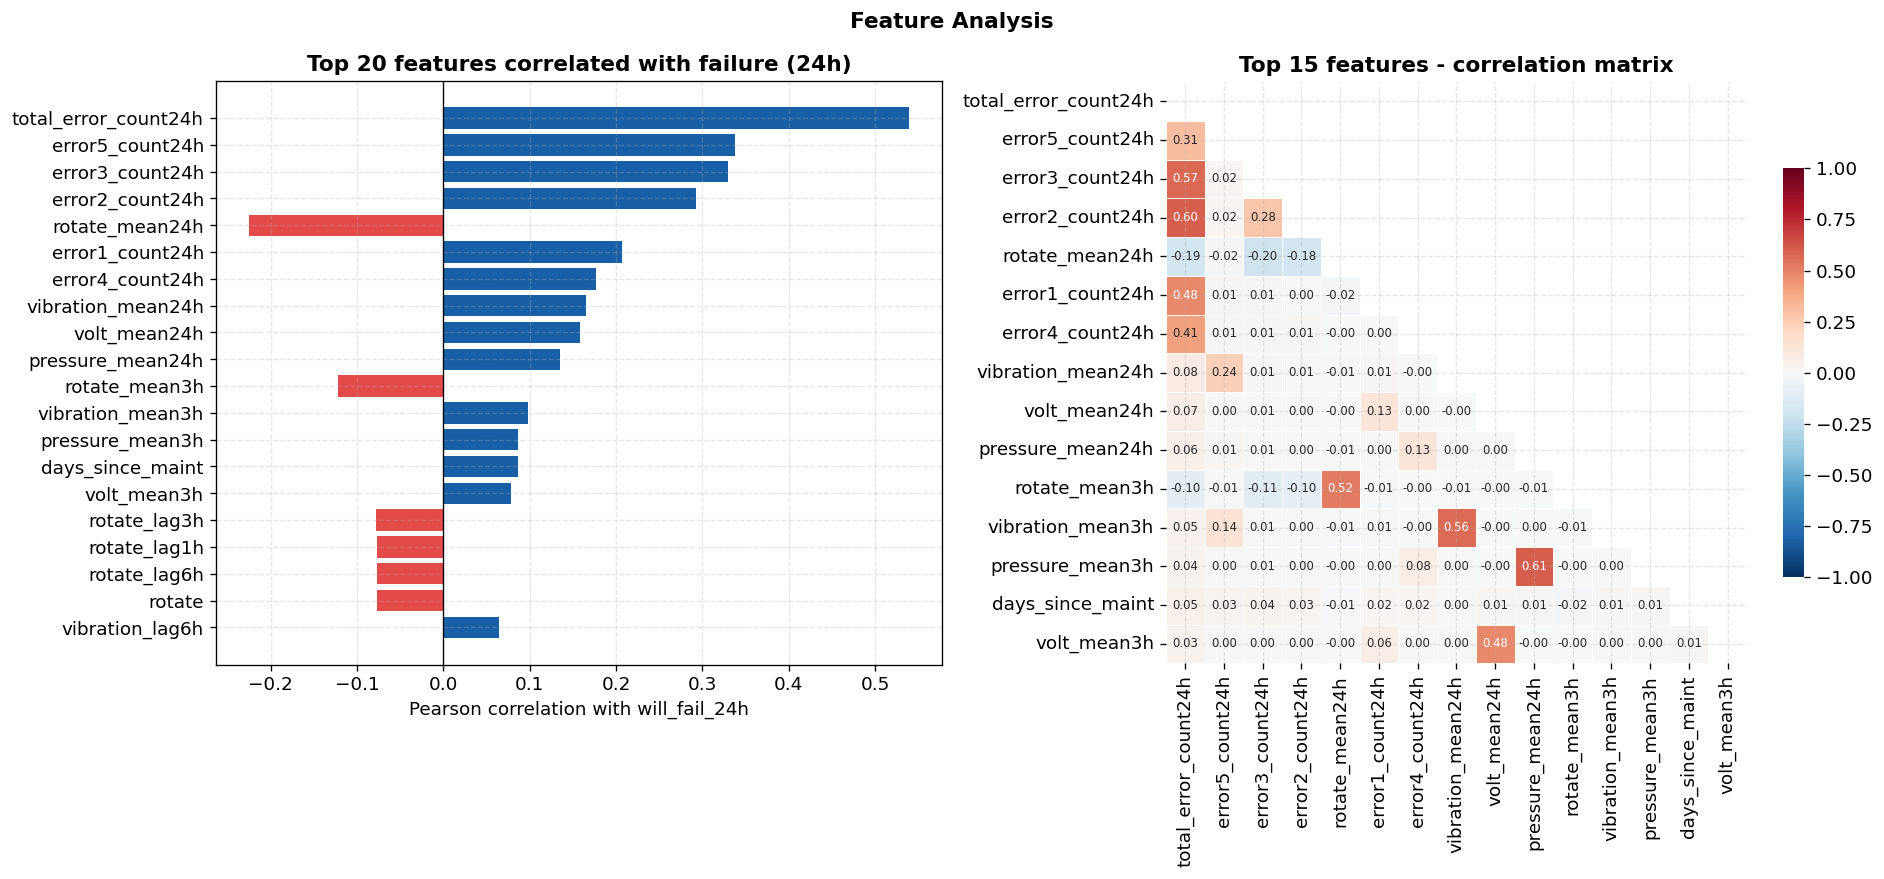


Top 10 features most correlated with failure:
total_error_count24h    0.5396
error5_count24h         0.3380
error3_count24h         0.3295
error2_count24h         0.2929
rotate_mean24h         -0.2254
error1_count24h         0.2069
error4_count24h         0.1763
vibration_mean24h       0.1657
volt_mean24h            0.1586
pressure_mean24h        0.1353


In [12]:
# Correlation with will_fail_24h (untuk insight feature importance)
corr_with_label = df[FEATURE_COLS + ['will_fail_24h']].corr()['will_fail_24h']
corr_with_label = corr_with_label.drop('will_fail_24h').sort_values(key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Feature Analysis', fontsize=13, fontweight='bold')

# Top 20 correlated features
top20 = corr_with_label.head(20)
colors = ['#E24B4A' if v < 0 else '#185FA5' for v in top20.values]
axes[0].barh(top20.index[::-1], top20.values[::-1], color=colors[::-1])
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Pearson correlation with will_fail_24h')
axes[0].set_title('Top 20 features correlated with failure (24h)')

# Feature correlation heatmap (top 15 only for readability)
top15_cols = corr_with_label.head(15).index.tolist()
corr_matrix = df[top15_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, ax=axes[1], mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.3, annot_kws={'size':7},
            cbar_kws={'shrink':0.7})
axes[1].set_title('Top 15 features - correlation matrix')
plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/08_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 features most correlated with failure:')
print(corr_with_label.head(10).round(4).to_string())


## 10. Normalize & Save

In [13]:
# Fix duplicate columns sebelum save
df = df.loc[:, ~df.columns.duplicated()]
print(f'Columns after dedup: {df.shape[1]}')
print(f'Remaining dupes: {df.columns.duplicated().sum()}')


Columns after dedup: 57
Remaining dupes: 0


In [14]:
print('Fitting StandardScaler on full dataset...')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[FEATURE_COLS].values)
df_scaled = pd.DataFrame(X_scaled, columns=[f'{c}_scaled' for c in FEATURE_COLS],
                          index=df.index)

# Save scaler
artifact = {
    'scaler'      : scaler,
    'feature_cols': FEATURE_COLS,
    'n_features'  : len(FEATURE_COLS),
}
joblib.dump(artifact, f'{MODELS_DIR}/scaler.pkl')
print(f'Scaler saved -> models/scaler.pkl')

# Combine: metadata + raw + features + labels (deduplicate columns)
META_COLS  = ['datetime','machineID','model','model_code','age']
LABEL_COLS = ['hours_to_failure','failure_type','will_fail_24h','will_fail_48h']

# Build ordered unique column list to avoid duplicates
_seen = set()
_cols = []
for c in META_COLS + SENSOR_COLS + FEATURE_COLS + LABEL_COLS:
    if c not in _seen:
        _seen.add(c)
        _cols.append(c)

df_final = pd.concat([
    df[_cols].reset_index(drop=True),
    df_scaled.reset_index(drop=True)
], axis=1)

# Final dedup safeguard
df_final = df_final.loc[:, ~df_final.columns.duplicated()]

# Save as parquet
out_path = f'{PROC_DIR}/features.parquet'
df_final.to_parquet(out_path, index=False)
print(f'Saved -> data/processed/features.parquet')
print(f'Shape : {df_final.shape}')
print(f'Size  : {os.path.getsize(out_path)/1024/1024:.1f} MB')
print(f'Columns: {len(df_final.columns)}')

# Save feature column list for reference
import json
with open(f'{MODELS_DIR}/feature_cols.json','w') as f:
    json.dump(FEATURE_COLS, f, indent=2)
print('Feature column list saved -> models/feature_cols.json')


Fitting StandardScaler on full dataset...


Scaler saved -> models/scaler.pkl


Saved -> data/processed/features.parquet
Shape : (876100, 96)
Size  : 503.1 MB
Columns: 96
Feature column list saved -> models/feature_cols.json


## 11. Sanity Check

In [15]:
# Reload and verify
df_check = pd.read_parquet(f'{PROC_DIR}/features.parquet')

print('Reload sanity check:')
print(f'  Shape           : {df_check.shape}')
print(f'  Machines        : {df_check["machineID"].nunique()}')
print(f'  Date range      : {df_check["datetime"].min()} -> {df_check["datetime"].max()}')
print(f'  NaN count       : {df_check.isnull().sum().sum()}')
print(f'  Failure rows 24h: {df_check["will_fail_24h"].sum():,}')
print(f'  Imbalance ratio : 1:{int(len(df_check)/df_check["will_fail_24h"].sum())}')

# Sample dari feature table
display(df_check[['datetime','machineID','volt','volt_mean24h',
                   'volt_std24h','vibration_roc','total_error_count24h',
                   'days_since_maint','will_fail_24h']].head(5))

print('\nPreprocessing selesai. Next: Notebook 03 - Modeling')


Reload sanity check:
  Shape           : (876100, 96)
  Machines        : 100
  Date range      : 2015-01-01 06:00:00 -> 2016-01-01 06:00:00


  NaN count       : 120746
  Failure rows 24h: 17,902
  Imbalance ratio : 1:48


,datetime,machineID,volt,volt_mean24h,volt_std24h,vibration_roc,total_error_count24h,days_since_maint,will_fail_24h
0,2015-01-01 06:00:00,1,176.217853,176.217853,0.000000,0.000000,0.0,19.000000,0
1,2015-01-01 07:00:00,1,162.879223,169.548538,9.431836,-1.673713,0.0,19.041667,0
2,2015-01-01 08:00:00,1,170.989902,170.028993,6.721032,-9.235126,0.0,19.083333,0
3,2015-01-01 09:00:00,1,162.462833,168.137453,6.665324,6.943297,0.0,19.125000,0
4,2015-01-01 10:00:00,1,157.610021,166.031967,7.448844,-15.131633,0.0,19.166667,0



Preprocessing selesai. Next: Notebook 03 - Modeling
